# Q2 — Numerical Prompt Baseline

**Question**: Does verbalizing bids as percentages in the prompt produce bid-monotone allocation?

**Hypothesis**: NO — the auction beats this baseline on monotonicity and welfare.

**Setup**: 5 prompts (first 5 from `agent_prompts.json`), 8 bid combos matching original 2-agent setup, k=20 samples per combo.
- **Numerical baseline**: standard FluxPipeline with prompt `"{base} that is {pct1}% aligned with {a1} and {pct2}% aligned with {a2}"`
- **Auction**: existing data at `alignment/alignment_clip_2_agents/prompt_{000..004}/`

See `claude_docs/04_2026/04_25/02_q2_numerical_baseline.md` for full details.

In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BASELINE_DIR = '../alignment/q2_numerical_clip'
AUCTION_DIR = '../alignment/alignment_clip_2_agents'
PROMPTS_PATH = '../prompts/q2_numerical.json'
RESULTS_DIR = '../results/q2_numerical_baseline'
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(PROMPTS_PATH) as f:
    PROMPTS = json.load(f)

BIDS_OF_INTEREST = [(0.0, 0.0), (1.0, 0.0), (0.1, 0.9), (0.9, 0.1),
                    (0.0, 1.0), (0.5, 0.5), (0.7, 0.3), (0.3, 0.7)]
print(f'{len(PROMPTS)} prompts, {len(BIDS_OF_INTEREST)} bid combos')

5 prompts, 8 bid combos


## 1. Load alignment data (both methods)

**Important**: All values come from disk — no hardcoded numbers.

In [2]:
def load_alignment(align_dir, prompt_indices=None, bids_filter=None):
    records = []
    if prompt_indices is None:
        prompt_indices = list(range(len(PROMPTS)))
    for pidx in prompt_indices:
        pdir = os.path.join(align_dir, f'prompt_{pidx:03d}')
        if not os.path.isdir(pdir):
            continue
        for jf in glob.glob(os.path.join(pdir, '*.json')):
            with open(jf) as f:
                d = json.load(f)
            meta = d['metadata']
            sc = d['alignment_scores']
            wf = d.get('welfare_metrics', {})
            b1, b2 = meta['bids'][0], meta['bids'][1]
            if bids_filter and not any(
                abs(b1 - bb1) < 1e-6 and abs(b2 - bb2) < 1e-6
                for bb1, bb2 in bids_filter):
                continue
            records.append({
                'prompt_idx': meta['prompt_index'],
                'b1': b1, 'b2': b2,
                'sample_idx': meta['sample_index'],
                'agent1_alignment': sc['agent1_alignment'],
                'agent2_alignment': sc['agent2_alignment'],
                'base_alignment': sc.get('base_alignment'),
                'total_welfare': wf.get('total_welfare'),
                'weighted_alignment': wf.get('weighted_alignment'),
            })
    return pd.DataFrame(records)

df_baseline = load_alignment(BASELINE_DIR)
df_auction = load_alignment(AUCTION_DIR, prompt_indices=list(range(5)), bids_filter=BIDS_OF_INTEREST)

print(f'Baseline: {len(df_baseline)} records across {df_baseline.prompt_idx.nunique() if len(df_baseline) else 0} prompts')
print(f'Auction:  {len(df_auction)} records across {df_auction.prompt_idx.nunique() if len(df_auction) else 0} prompts')
if len(df_baseline) > 0:
    print(f'  Baseline samples/combo: {df_baseline.groupby(["prompt_idx", "b1", "b2"]).size().describe()}')
if len(df_auction) > 0:
    print(f'  Auction samples/combo: {df_auction.groupby(["prompt_idx", "b1", "b2"]).size().describe()}')

Baseline: 200 records across 5 prompts
Auction:  2000 records across 5 prompts
  Baseline samples/combo: count    40.0
mean      5.0
std       0.0
min       5.0
25%       5.0
50%       5.0
75%       5.0
max       5.0
dtype: float64
  Auction samples/combo: count    40.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0
dtype: float64


## 2. Aggregate by combo (welfare-optimal + mean across samples)

In [3]:
def aggregate(df, label):
    if len(df) == 0:
        return df
    rows = []
    for (p, b1, b2), g in df.groupby(['prompt_idx', 'b1', 'b2']):
        # Welfare-optimal: pick highest total_welfare sample
        if g['total_welfare'].notna().any():
            best = g.loc[g['total_welfare'].idxmax()]
            wo_a1 = best['agent1_alignment']
            wo_a2 = best['agent2_alignment']
        else:
            wo_a1 = wo_a2 = float('nan')
        rows.append({
            'method': label,
            'prompt_idx': p, 'b1': b1, 'b2': b2,
            'a1_mean': g['agent1_alignment'].mean(),
            'a1_std': g['agent1_alignment'].std(),
            'a2_mean': g['agent2_alignment'].mean(),
            'a2_std': g['agent2_alignment'].std(),
            'a1_wo': wo_a1, 'a2_wo': wo_a2,
            'n_samples': len(g),
        })
    return pd.DataFrame(rows).sort_values(['prompt_idx', 'b1', 'b2'])

df_b_agg = aggregate(df_baseline, 'numerical_baseline')
df_a_agg = aggregate(df_auction, 'auction')
df_compare = pd.concat([df_b_agg, df_a_agg], ignore_index=True) if len(df_b_agg) and len(df_a_agg) else (df_b_agg if len(df_b_agg) else df_a_agg)
print(df_compare.head(20) if len(df_compare) > 0 else 'No data')

                method  prompt_idx   b1   b2   a1_mean    a1_std   a2_mean  \
0   numerical_baseline           0  0.0  0.0  0.159570  0.015264  0.123340   
1   numerical_baseline           0  0.0  1.0  0.157422  0.007640  0.174805   
2   numerical_baseline           0  0.1  0.9  0.156445  0.029632  0.179297   
3   numerical_baseline           0  0.3  0.7  0.159180  0.013897  0.197070   
4   numerical_baseline           0  0.5  0.5  0.164844  0.015948  0.176758   
5   numerical_baseline           0  0.7  0.3  0.163672  0.015170  0.185938   
6   numerical_baseline           0  0.9  0.1  0.171094  0.008746  0.206641   
7   numerical_baseline           0  1.0  0.0  0.203516  0.010733  0.123535   
8   numerical_baseline           1  0.0  0.0  0.083691  0.013136  0.077734   
9   numerical_baseline           1  0.0  1.0  0.083496  0.006632  0.181836   
10  numerical_baseline           1  0.1  0.9  0.153906  0.065388  0.218945   
11  numerical_baseline           1  0.3  0.7  0.107227  0.023606

## 3. Per-prompt comparison: alignment vs `b1`
Each prompt is a column. Top row: agent 1 alignment. Bottom: agent 2.

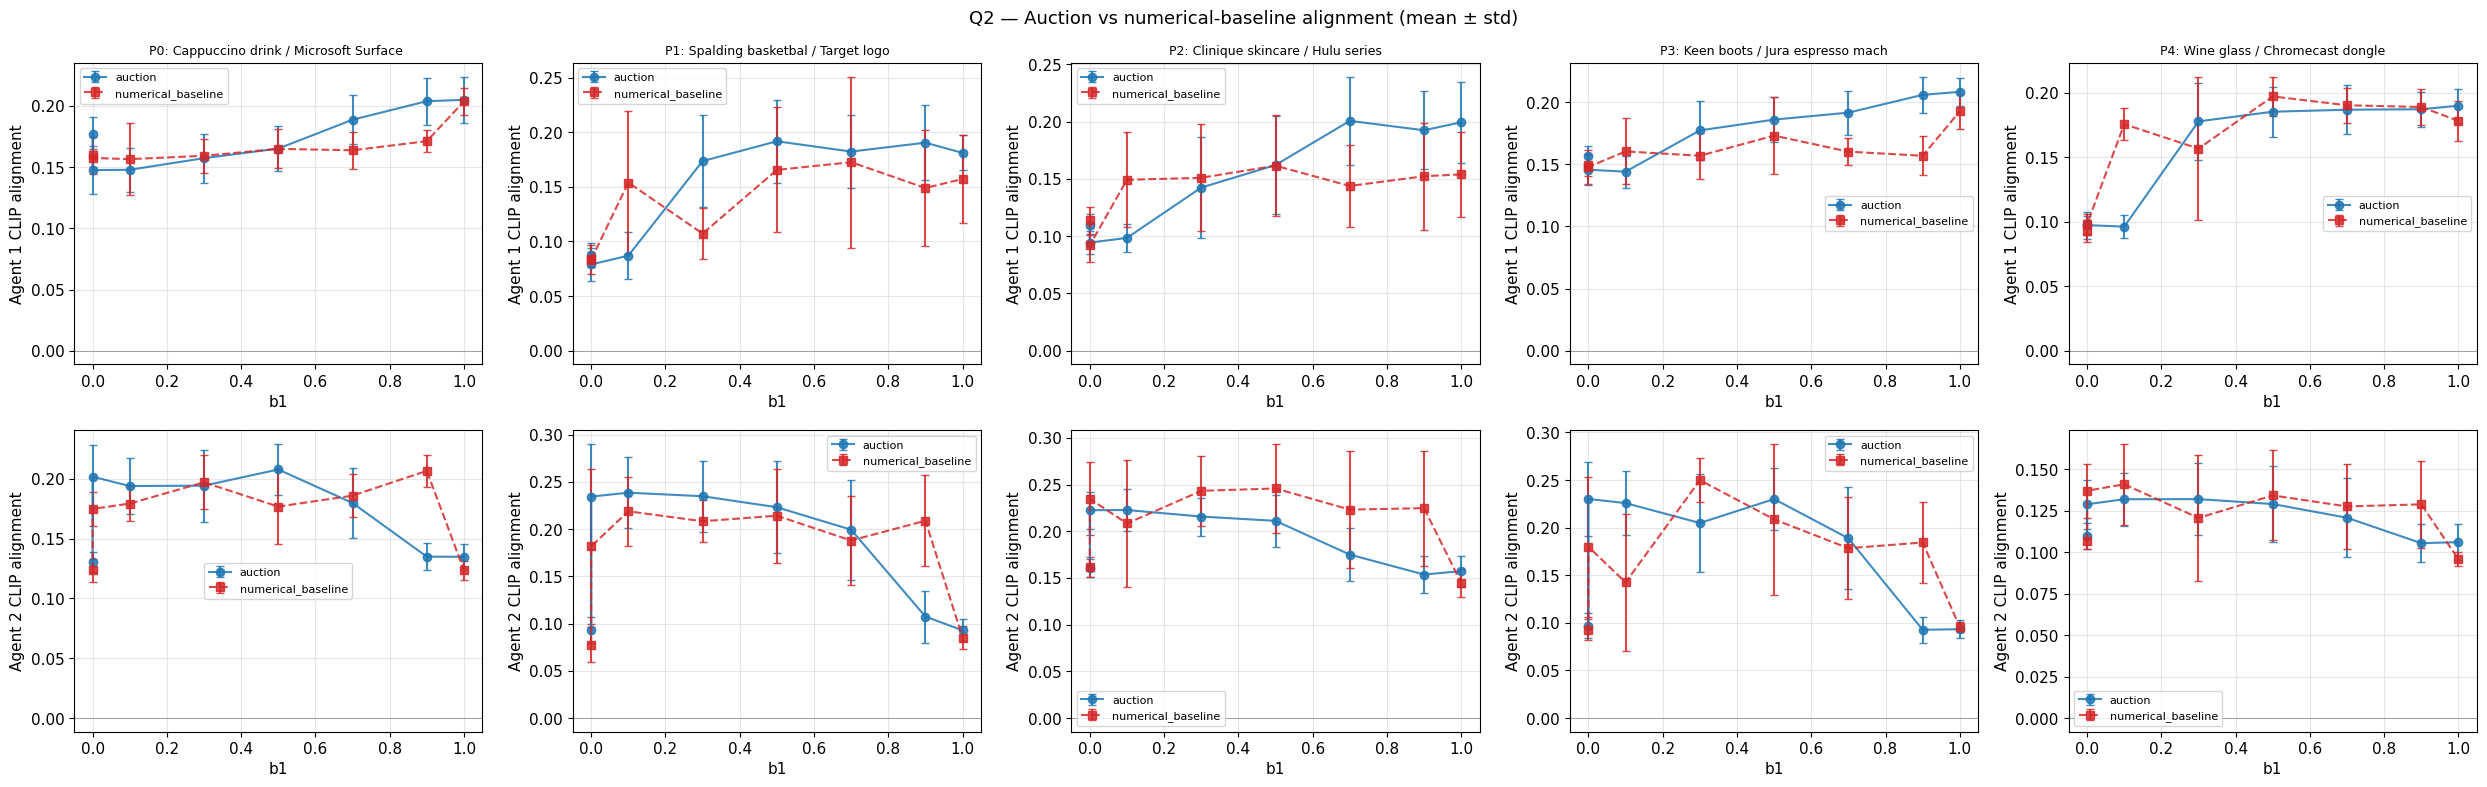

In [4]:
def plot_per_prompt_comparison(df_compare):
    if len(df_compare) == 0:
        print('No data'); return None
    pidxs = sorted(df_compare.prompt_idx.unique())
    n = len(pidxs)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8), squeeze=False)
    method_styles = {'auction': ('o-', 'tab:blue'), 'numerical_baseline': ('s--', 'tab:red')}
    for col, p in enumerate(pidxs):
        sub = df_compare[df_compare.prompt_idx == p]
        for r, agent_col, agent_label in [(0, 'a1_mean', 'Agent 1'), (1, 'a2_mean', 'Agent 2')]:
            ax = axes[r, col]
            for method, (marker, color) in method_styles.items():
                ms = sub[sub.method == method].sort_values('b1')
                if len(ms) == 0:
                    continue
                std_col = agent_col.replace('_mean', '_std')
                ax.errorbar(ms.b1, ms[agent_col], yerr=ms[std_col],
                            fmt=marker, color=color, label=method, capsize=3, alpha=0.85)
            ax.set_xlabel('b1')
            ax.set_ylabel(f'{agent_label} CLIP alignment')
            if r == 0:
                ax.set_title(f'P{p}: {PROMPTS[p]["agent1_prompt"][:18]} / {PROMPTS[p]["agent2_prompt"][:18]}', fontsize=9)
            ax.axhline(0, color='gray', lw=0.5)
            ax.legend(fontsize=8)
    fig.suptitle('Q2 — Auction vs numerical-baseline alignment (mean ± std)', fontsize=13)
    plt.tight_layout()
    return fig

fig = plot_per_prompt_comparison(df_compare)
if fig:
    fig.savefig(os.path.join(RESULTS_DIR, 'comparison_per_prompt.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 4. Welfare comparison
Welfare = `b1 * agent1_alignment + b2 * agent2_alignment` (computed from the data).

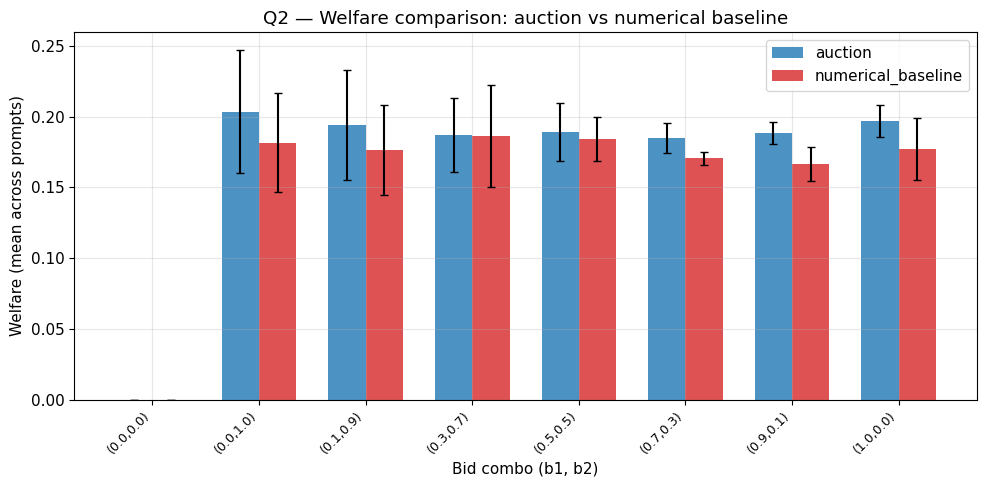

In [5]:
def add_welfare(df_agg):
    df = df_agg.copy()
    df['welfare'] = df['b1'] * df['a1_mean'] + df['b2'] * df['a2_mean']
    return df

df_compare_w = add_welfare(df_compare)

def plot_welfare_comparison(df_w):
    if len(df_w) == 0:
        print('No data'); return None
    fig, ax = plt.subplots(figsize=(10, 5))
    # Mean welfare across prompts per (b1, b2, method)
    grp = df_w.groupby(['method', 'b1', 'b2']).agg(
        welfare_mean=('welfare', 'mean'),
        welfare_std=('welfare', 'std'),
    ).reset_index()
    # Identify combos by index
    grp['combo'] = grp.apply(lambda r: f'({r.b1:.1f},{r.b2:.1f})', axis=1)
    methods = grp.method.unique()
    combos = grp.combo.unique()
    width = 0.35
    x = np.arange(len(combos))
    method_colors = {'auction': 'tab:blue', 'numerical_baseline': 'tab:red'}
    for i, m in enumerate(methods):
        sub = grp[grp.method == m].set_index('combo').reindex(combos)
        ax.bar(x + (i - 0.5) * width, sub.welfare_mean, width, yerr=sub.welfare_std,
               capsize=3, label=m, color=method_colors.get(m, 'tab:gray'), alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(combos, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Bid combo (b1, b2)')
    ax.set_ylabel('Welfare (mean across prompts)')
    ax.set_title('Q2 — Welfare comparison: auction vs numerical baseline')
    ax.legend()
    plt.tight_layout()
    return fig

fig = plot_welfare_comparison(df_compare_w)
if fig:
    fig.savefig(os.path.join(RESULTS_DIR, 'welfare_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 4b. Average welfare improvement summary

Compute % improvement of auction over numerical baseline per non-zero bid combo,
plus an overall mean improvement.

Welfare improvement of auction over numerical baseline (per combo):
 b1  b2  auction_welfare  baseline_welfare  improvement_pct
0.0 1.0         0.203561          0.181641        12.067742
0.1 0.9         0.193811          0.176117        10.046633
0.3 0.7         0.187141          0.186545         0.319335
0.5 0.5         0.189122          0.184180         2.683457
0.7 0.3         0.184807          0.170447         8.424641
0.9 0.1         0.188213          0.166324        13.160185
1.0 0.0         0.196699          0.177070        11.085374

Overall mean improvement (averaged across 7 non-zero combos): 8.26%
Saved ../results/q2_numerical_baseline/welfare_improvement_summary.csv


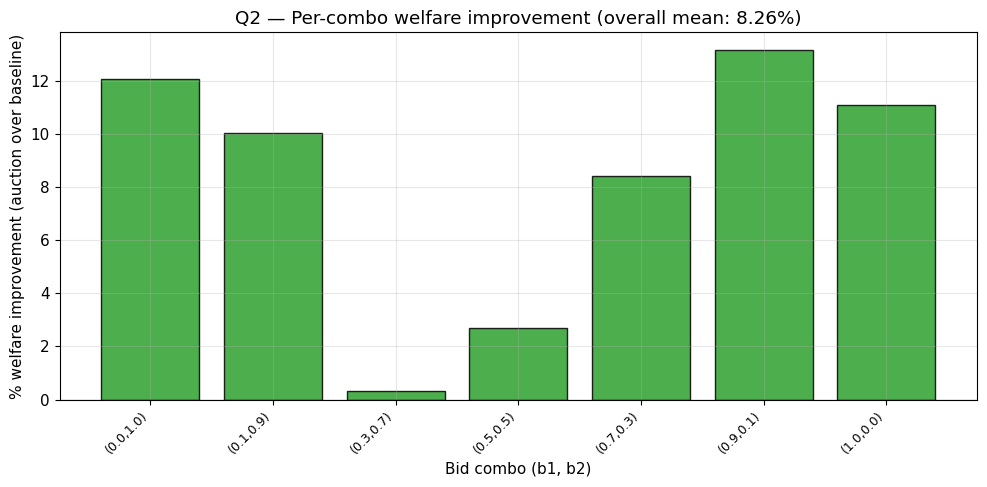

Saved ../results/q2_numerical_baseline/welfare_improvement_by_combo.png


In [6]:
# Cell A — average welfare improvement summary

# Mean welfare per (method, b1, b2) across all prompts
welfare_by_combo = (
    df_compare_w.groupby(['method', 'b1', 'b2'])['welfare']
    .mean().reset_index()
)

# Pivot so each combo has both methods as columns
pivot = welfare_by_combo.pivot_table(
    index=['b1', 'b2'], columns='method', values='welfare'
).reset_index()

# Filter to non-zero bid combos (b1 + b2 > 0)
pivot_nz = pivot[(pivot['b1'] + pivot['b2']) > 1e-9].copy()

# % improvement: 100 * (auction - baseline) / baseline
pivot_nz['improvement_pct'] = (
    100.0 * (pivot_nz['auction'] - pivot_nz['numerical_baseline'])
    / pivot_nz['numerical_baseline']
)

summary_df = pivot_nz.rename(columns={
    'auction': 'auction_welfare',
    'numerical_baseline': 'baseline_welfare',
})[['b1', 'b2', 'auction_welfare', 'baseline_welfare', 'improvement_pct']]
summary_df = summary_df.sort_values(['b1', 'b2']).reset_index(drop=True)

print('Welfare improvement of auction over numerical baseline (per combo):')
print(summary_df.to_string(index=False))

overall_mean_improvement = summary_df['improvement_pct'].mean()
print(f'\nOverall mean improvement (averaged across {len(summary_df)} non-zero combos): '
      f'{overall_mean_improvement:.2f}%')

# Save CSV
csv_path = os.path.join(RESULTS_DIR, 'welfare_improvement_summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f'Saved {csv_path}')

# Bar plot
fig, ax = plt.subplots(figsize=(10, 5))
combo_labels = [f'({b1:.1f},{b2:.1f})' for b1, b2 in zip(summary_df['b1'], summary_df['b2'])]
colors = ['tab:green' if v >= 0 else 'tab:red' for v in summary_df['improvement_pct']]
x = np.arange(len(summary_df))
ax.bar(x, summary_df['improvement_pct'], color=colors, alpha=0.85, edgecolor='black')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Bid combo (b1, b2)')
ax.set_ylabel('% welfare improvement (auction over baseline)')
ax.set_title(f'Q2 — Per-combo welfare improvement (overall mean: {overall_mean_improvement:.2f}%)')
plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'welfare_improvement_by_combo.png')
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {plot_path}')

## 4c. Per-agent average alignment (auction vs baseline)

Mean alignment vs `b1` for each agent, with auction in blue and baseline in red.

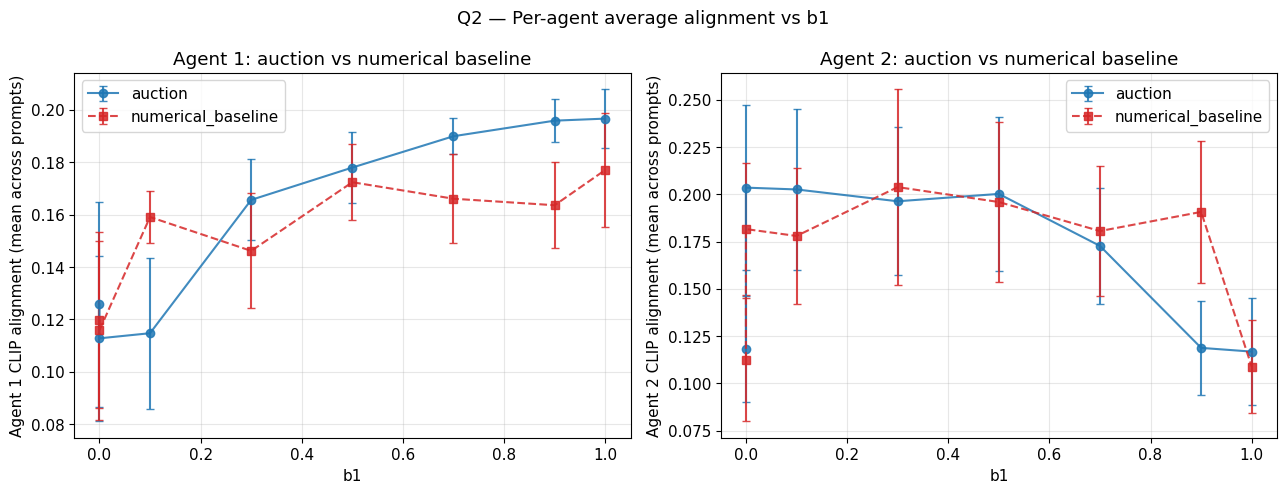

Saved ../results/q2_numerical_baseline/alignment_per_agent_avg.png

Slope of mean alignment vs b1 (linear regression):
 auction_a1_slope  auction_a2_slope  numerical_baseline_a1_slope  numerical_baseline_a2_slope
         0.086195         -0.051472                     0.047143                    -0.006862

|auction a1 slope| = 0.0862, |baseline a1 slope| = 0.0471
|auction a2 slope| = 0.0515, |baseline a2 slope| = 0.0069


In [7]:
# Cell B — per-agent average alignment (auction vs baseline)

# df_compare_w already has per-(method, prompt, b1, b2) means.
# Average over prompts to get per-(method, b1, b2) values, with std across prompts.
agent_avg = (
    df_compare_w.groupby(['method', 'b1', 'b2'])
    .agg(a1_mean=('a1_mean', 'mean'),
         a1_std=('a1_mean', 'std'),
         a2_mean=('a2_mean', 'mean'),
         a2_std=('a2_mean', 'std'))
    .reset_index()
)

method_colors = {'auction': 'tab:blue', 'numerical_baseline': 'tab:red'}
method_markers = {'auction': 'o-', 'numerical_baseline': 's--'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for col, (agent_idx, mean_col, std_col) in enumerate([
    (1, 'a1_mean', 'a1_std'),
    (2, 'a2_mean', 'a2_std'),
]):
    ax = axes[col]
    for method in ['auction', 'numerical_baseline']:
        ms = agent_avg[agent_avg.method == method].sort_values('b1')
        ax.errorbar(
            ms['b1'], ms[mean_col], yerr=ms[std_col],
            fmt=method_markers[method], color=method_colors[method],
            label=method, capsize=3, alpha=0.85,
        )
    ax.set_xlabel('b1')
    ax.set_ylabel(f'Agent {agent_idx} CLIP alignment (mean across prompts)')
    ax.set_title(f'Agent {agent_idx}: auction vs numerical baseline')
    ax.legend()
fig.suptitle('Q2 — Per-agent average alignment vs b1', fontsize=13)
plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'alignment_per_agent_avg.png')
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {plot_path}')

# Slope table — slope of each curve via simple linear regression on b1
def slope(xs, ys):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    if len(xs) < 2 or np.std(xs) < 1e-12:
        return float('nan')
    return float(np.polyfit(xs, ys, 1)[0])

slopes = {}
for method in ['auction', 'numerical_baseline']:
    sub = agent_avg[agent_avg.method == method].sort_values('b1')
    slopes[f'{method}_a1_slope'] = slope(sub['b1'], sub['a1_mean'])
    slopes[f'{method}_a2_slope'] = slope(sub['b1'], sub['a2_mean'])

slopes_df = pd.DataFrame([slopes])
print('\nSlope of mean alignment vs b1 (linear regression):')
print(slopes_df.to_string(index=False))
print(
    f"\n|auction a1 slope| = {abs(slopes['auction_a1_slope']):.4f}, "
    f"|baseline a1 slope| = {abs(slopes['numerical_baseline_a1_slope']):.4f}"
)
print(
    f"|auction a2 slope| = {abs(slopes['auction_a2_slope']):.4f}, "
    f"|baseline a2 slope| = {abs(slopes['numerical_baseline_a2_slope']):.4f}"
)

## 5. Monotonicity check
For each (prompt, agent), check whether alignment is non-decreasing as that agent's bid increases.

In [8]:
def monotonicity_summary(df_agg):
    """For each (method, prompt), check monotonicity of agent1 alignment vs b1
    (along combos sorted by b1 with b2 fixed).
    Returns rows: method, prompt_idx, agent, n_pairs, n_monotone.
    Only checks pairs where the OTHER agent's bid is the same (clean comparison).
    """
    rows = []
    for (m, p), g in df_agg.groupby(['method', 'prompt_idx']):
        g = g.sort_values(['b1', 'b2'])
        # Check all (i, j) pairs where b2_i = b2_j and b1_i < b1_j
        for fixed_b2 in sorted(g.b2.unique()):
            sub = g[g.b2 == fixed_b2].sort_values('b1').reset_index(drop=True)
            for i in range(len(sub) - 1):
                for j in range(i+1, len(sub)):
                    if sub.loc[i, 'a1_mean'] <= sub.loc[j, 'a1_mean']:
                        result = 1
                    else:
                        result = 0
                    rows.append({'method': m, 'prompt_idx': p, 'agent': 1,
                                 'monotone': result, 'fixed_other': fixed_b2})
        # Same for agent 2: pairs where b1 fixed, b2 varies
        for fixed_b1 in sorted(g.b1.unique()):
            sub = g[g.b1 == fixed_b1].sort_values('b2').reset_index(drop=True)
            for i in range(len(sub) - 1):
                for j in range(i+1, len(sub)):
                    if sub.loc[i, 'a2_mean'] <= sub.loc[j, 'a2_mean']:
                        result = 1
                    else:
                        result = 0
                    rows.append({'method': m, 'prompt_idx': p, 'agent': 2,
                                 'monotone': result, 'fixed_other': fixed_b1})
    return pd.DataFrame(rows)

if len(df_compare) > 0:
    df_mono = monotonicity_summary(df_compare)
    summary = df_mono.groupby(['method', 'agent']).agg(
        n_pairs=('monotone', 'count'),
        n_monotone=('monotone', 'sum'),
    ).reset_index()
    summary['pct_monotone'] = 100.0 * summary.n_monotone / summary.n_pairs
    print(summary.to_string(index=False))
    summary.to_csv(os.path.join(RESULTS_DIR, 'monotonicity_summary.csv'), index=False)

            method  agent  n_pairs  n_monotone  pct_monotone
           auction      1        5           5         100.0
           auction      2        5           5         100.0
numerical_baseline      1        5           5         100.0
numerical_baseline      2        5           5         100.0


## 6. Export

In [9]:
if len(df_compare_w) > 0:
    df_compare_w.to_csv(os.path.join(RESULTS_DIR, 'comparison_data.csv'), index=False)
    print(f'Saved {len(df_compare_w)} rows to comparison_data.csv')

Saved 80 rows to comparison_data.csv
